# ECG Heartbeat Classification - 1D CNN


## Cell 1 - GPU Check

In [ ]:
import tensorflow as tf

gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print(f'GPU available: {gpus}')
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    print('No GPU detected - running on CPU (slower)')
    print('Go to: Runtime -> Change runtime type -> T4 GPU')

print(f'TensorFlow version: {tf.__version__}')

GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TensorFlow version: 2.20.0


## Cell 2 - Package Versions


In [ ]:
# Colab has most packages pre-installed
import sklearn, pandas, numpy, seaborn

print(f'scikit-learn : {sklearn.__version__}')
print(f'pandas       : {pandas.__version__}')
print(f'numpy        : {numpy.__version__}')
print(f'seaborn      : {seaborn.__version__}')
print(f'tensorflow   : {tf.__version__}')
print('All packages available')

scikit-learn : 1.6.1
pandas       : 2.2.2
numpy        : 2.0.2
seaborn      : 0.13.2
tensorflow   : 2.20.0
All packages available


## Cell 3 - Upload CSV Files


In [ ]:
from google.colab import files
import io

print('Select files to upload')
uploaded = files.upload()

print(f'Uploaded {len(uploaded)} file(s):')
for fname, data in uploaded.items():
    print(f'   {fname}  ({len(data)/1024/1024:.1f} MB)')

Select files to upload


Saving mitbih_test.csv to mitbih_test (1).csv
Saving mitbih_train.csv to mitbih_train (1).csv
Saving ptbdb_abnormal.csv to ptbdb_abnormal.csv
Saving ptbdb_normal.csv to ptbdb_normal.csv
Uploaded 4 file(s):
   mitbih_test (1).csv  (98.1 MB)
   mitbih_train (1).csv  (392.4 MB)
   ptbdb_abnormal.csv  (47.1 MB)
   ptbdb_normal.csv  (18.1 MB)


## Cell 4 - Imports and Configuration

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import os
from itertools import cycle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, f1_score, roc_curve, auc
)
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D, MaxPooling1D, Dense, Dropout,
    GlobalAveragePooling1D, BatchNormalization
)
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam, RMSprop

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

os.makedirs('figures', exist_ok=True)

print('All imports successful')

All imports successful


## Cell 5 - Focal Loss Definition
The MIT-BIH dataset is heavily imbalanced (class 0 has 82% of samples, class 3 only 0.7%). Focal Loss forces the model to focus on hard examples instead of ignoring minority classes.

In [ ]:
def focal_loss(gamma=2.0, alpha=None):
    """
    Focal Loss for imbalanced class distributions.

    Parameters:
        gamma : float -- focusing parameter, 2.0 is the standard value.
                Higher gamma = more focus on hard, misclassified examples.
        alpha : tf.Tensor -- per-class weights of length num_classes.
                Computed via compute_class_weight('balanced').
    """
    def loss_fn(y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)

        p_t = tf.reduce_sum(y_true * y_pred, axis=-1)

        ce = -tf.math.log(p_t)

        focal_weight = tf.pow(1.0 - p_t, gamma)

        if alpha is not None:
            class_idx = tf.argmax(y_true, axis=-1)
            alpha_t = tf.gather(alpha, class_idx)
            return alpha_t * focal_weight * ce

        return focal_weight * ce

    return loss_fn

print('Focal Loss defined')

Focal Loss defined


## Cell 6 - Data Loading and Preparation


In [ ]:
print('=' * 60)
print('LOADING DATA')
print('=' * 60)

data_train = pd.read_csv(io.BytesIO(uploaded['mitbih_train (1).csv']), header=None)
data_test  = pd.read_csv(io.BytesIO(uploaded['mitbih_test (1).csv']),  header=None)

X_full = pd.concat([data_train.iloc[:, :-1], data_test.iloc[:, :-1]], axis=0).reset_index(drop=True)
y_full = pd.concat([data_train.iloc[:, -1],  data_test.iloc[:, -1]],  axis=0).reset_index(drop=True)
y_full = y_full.astype(int)

print(f'Total samples : {len(X_full):,}')
print(f'Features      : {X_full.shape[1]}')
print(f'\nClass distribution:')
for cls in sorted(y_full.unique()):
    cnt = (y_full == cls).sum()
    print(f'  Class {cls}: {cnt:6,} ({100*cnt/len(y_full):5.1f}%)')

X_temp, X_test, y_temp, y_test = train_test_split(
    X_full, y_full, test_size=0.2, random_state=42, stratify=y_full)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

# Standardization
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

# Reshape for 1D CNN
X_train_r = X_train_scaled.reshape(-1, X_train_scaled.shape[1], 1)
X_val_r   = X_val_scaled.reshape(-1,   X_val_scaled.shape[1],   1)
X_test_r  = X_test_scaled.reshape(-1,  X_test_scaled.shape[1],  1)

# One-hot encode labels
y_train_cat = to_categorical(y_train, num_classes=5)
y_val_cat   = to_categorical(y_val,   num_classes=5)
y_test_cat  = to_categorical(y_test,  num_classes=5)

print(f'\nDataset shapes:')
print(f'  Train : {X_train_r.shape}')
print(f'  Val   : {X_val_r.shape}')
print(f'  Test  : {X_test_r.shape}')

# Class weights for Focal Loss alpha
class_weights_arr = compute_class_weight(
    'balanced', classes=np.arange(5), y=y_train.values)

print(f'\nClass weights (balanced):')
for i, w in enumerate(class_weights_arr):
    print(f'  Class {i}: {w:.4f}')

alpha_tensor = tf.constant(class_weights_arr, dtype=tf.float32)
loss_fn = focal_loss(gamma=2.0, alpha=alpha_tensor)

print('\nData preparation complete')

LOADING DATA
Total samples : 109,446
Features      : 187

Class distribution:
  Class 0: 90,589 ( 82.8%)
  Class 1:  2,779 (  2.5%)
  Class 2:  7,236 (  6.6%)
  Class 3:    803 (  0.7%)
  Class 4:  8,039 (  7.3%)

Dataset shapes:
  Train : (65667, 187, 1)
  Val   : (21889, 187, 1)
  Test  : (21890, 187, 1)

Class weights (balanced):
  Class 0: 0.2416
  Class 1: 7.8785
  Class 2: 3.0247
  Class 3: 27.2477
  Class 4: 2.7231

Data preparation complete


## Cell 7 - CNN Model Definition


In [ ]:
def build_cnn(num_conv_layers=2, filters=64, kernel_size=5,
              dropout_rate=0.3, dense_units=128,
              learning_rate=0.001, optimizer='adam', l2_reg=0.001,
              input_shape=(187, 1)):

    model = Sequential()

    for i in range(num_conv_layers):
        f = int(filters * (2 ** i))
        kwargs = dict(
            filters=f,
            kernel_size=int(kernel_size),
            activation='relu',
            padding='same',
        )
        if l2_reg > 0:
            kwargs['kernel_regularizer'] = l2(float(l2_reg))
        if i == 0:
            kwargs['input_shape'] = input_shape

        model.add(Conv1D(**kwargs))
        model.add(BatchNormalization())
        model.add(MaxPooling1D(pool_size=2))
        model.add(Dropout(float(dropout_rate)))

    model.add(GlobalAveragePooling1D())
    model.add(Dense(int(dense_units), activation='relu'))
    model.add(Dropout(float(dropout_rate)))
    model.add(Dense(5, activation='softmax'))

    opt = (Adam(learning_rate=float(learning_rate))
           if optimizer == 'adam'
           else RMSprop(learning_rate=float(learning_rate)))

    model.compile(loss=loss_fn, optimizer=opt, metrics=['accuracy'])
    return model


test_model = build_cnn()
test_model.summary()
del test_model
print('\nbuild_cnn() ready')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 187, 64)        │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 187, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 93, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 93, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 93, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 59,397 (232.02 KB)

 Trainable params: 59,013 (230.52 KB)

 Non-trainable params: 384 (1.50 KB)


build_cnn() ready


## Cell 8 - Hyperparameter Search

In [ ]:
print('HYPERPARAMETER SEARCH (30 configurations)')

hyperparams_grid = {
    'num_conv_layers': [1, 2],
    'filters'        : [32, 64],
    'kernel_size'    : [3, 5],
    'dropout_rate'   : [0.3, 0.5],
    'dense_units'    : [64, 128],
    'learning_rate'  : [0.001, 0.0005],
    'optimizer'      : ['adam', 'rmsprop'],
    'batch_size'     : [32, 64],
    'l2_reg'         : [0.0, 0.001],
}

num_configs = 30
config_list = [
    {key: np.random.choice(values) for key, values in hyperparams_grid.items()}
    for _ in range(num_configs)
]

search_results = []
start_time_search = time.time()

for idx, config in enumerate(config_list):
    batch_size   = int(config['batch_size'])
    model_config = {k: v for k, v in config.items() if k != 'batch_size'}

    model = build_cnn(**model_config)

    early_stop = EarlyStopping(
        monitor='val_loss', patience=5,
        restore_best_weights=True, verbose=0)

    history = model.fit(
        X_train_r, y_train_cat,
        validation_data=(X_val_r, y_val_cat),
        epochs=50,
        batch_size=batch_size,
        callbacks=[early_stop],
        verbose=0
    )

    y_val_pred = np.argmax(model.predict(X_val_r, verbose=0), axis=1)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

    search_results.append({'config': config, 'f1_weighted': val_f1, 'model': model})

    if (idx + 1) % 5 == 0:
        best_so_far = max(search_results, key=lambda x: x['f1_weighted'])['f1_weighted']
        elapsed = (time.time() - start_time_search) / 60
        print(f'  [{idx+1:2d}/{num_configs}]  best F1: {best_so_far:.4f}  |  elapsed: {elapsed:.1f} min')

elapsed_search = time.time() - start_time_search
print(f'\nSearch completed in {elapsed_search/60:.1f} minutes')

sorted_results = sorted(search_results, key=lambda x: x['f1_weighted'], reverse=True)
print('\nTop 5 configurations:')
for rank, r in enumerate(sorted_results[:5], 1):
    print(f'  #{rank}  F1={r["f1_weighted"]:.4f}  |  ', end='')
    print({k: v for k, v in r['config'].items() if k in ['num_conv_layers','filters','optimizer','learning_rate']})

HYPERPARAMETER SEARCH (30 configurations)
  [ 5/30]  best F1: 0.8348  |  elapsed: 10.3 min
  [10/30]  best F1: 0.8830  |  elapsed: 24.5 min
  [15/30]  best F1: 0.8830  |  elapsed: 36.6 min
  [20/30]  best F1: 0.9174  |  elapsed: 51.9 min
  [25/30]  best F1: 0.9174  |  elapsed: 64.0 min
  [30/30]  best F1: 0.9174  |  elapsed: 77.0 min

Search completed in 77.0 minutes

Top 5 configurations:
  #1  F1=0.9174  |  {'num_conv_layers': np.int64(2), 'filters': np.int64(64), 'learning_rate': np.float64(0.001), 'optimizer': np.str_('adam')}
  #2  F1=0.9010  |  {'num_conv_layers': np.int64(2), 'filters': np.int64(64), 'learning_rate': np.float64(0.001), 'optimizer': np.str_('adam')}
  #3  F1=0.8830  |  {'num_conv_layers': np.int64(2), 'filters': np.int64(32), 'learning_rate': np.float64(0.0005), 'optimizer': np.str_('adam')}
  #4  F1=0.8682  |  {'num_conv_layers': np.int64(2), 'filters': np.int64(32), 'learning_rate': np.float64(0.0005), 'optimizer': np.str_('adam')}
  #5  F1=0.8678  |  {'num_con

## Cell 9 - Final Training


In [ ]:
print('=' * 60)
print('FINAL TRAINING')
print('=' * 60)

best_result = max(search_results, key=lambda x: x['f1_weighted'])
best_config = best_result['config']

print('\nBest configuration:')
for key, val in best_config.items():
    print(f'  {key:20s}: {val}')
print(f'  {"Val F1 (weighted)":20s}: {best_result["f1_weighted"]:.4f}')

X_train_final = np.vstack([X_train_r, X_val_r])
y_train_final = np.vstack([y_train_cat, y_val_cat])

batch_size_final   = int(best_config['batch_size'])
model_config_final = {k: v for k, v in best_config.items() if k != 'batch_size'}

final_model = build_cnn(**model_config_final)

callbacks_final = [
    EarlyStopping(monitor='val_loss', patience=8,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=4, verbose=1)
]

print('\nTraining...')
start_time_final = time.time()

history_final = final_model.fit(
    X_train_final, y_train_final,
    validation_split=0.1,
    epochs=100,
    batch_size=batch_size_final,
    callbacks=callbacks_final,
    verbose=1
)

elapsed_final = time.time() - start_time_final
print(f'\nTraining completed in {elapsed_final/60:.1f} minutes')

FINAL TRAINING

Best configuration:
  num_conv_layers     : 2
  filters             : 64
  kernel_size         : 5
  dropout_rate        : 0.3
  dense_units         : 128
  learning_rate       : 0.001
  optimizer           : adam
  batch_size          : 64
  l2_reg              : 0.001
  Val F1 (weighted)   : 0.9174

Training...
Epoch 1/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 17s 9ms/step - accuracy: 0.4711 - loss: 0.5561 - val_accuracy: 0.4906 - val_loss: 0.3738 - learning_rate: 0.0010
Epoch 2/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6514 - loss: 0.3573 - val_accuracy: 0.8132 - val_loss: 0.3022 - learning_rate: 0.0010
Epoch 3/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7122 - loss: 0.3093 - val_accuracy: 0.8482 - val_loss: 0.2465 - learning_rate: 0.0010
Epoch 4/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.7454 - loss: 0.2821 - val_accuracy: 0.7717 - val_loss: 0.2209 - learning_rate: 0.0010
Epoch 5/100
1232/1232 ━━━━━━━━━━━━━━━━━━━━ 5s 4

## Cell 10 - Evaluation and Visualizations


TEST SET EVALUATION

Predicted vs actual class distribution:
Class       Predicted       Actual
-----------------------------------
  0            16,283       18,118
  1             1,651          556
  2             1,678        1,447
  3               622          161
  4             1,656        1,608

Accuracy      : 0.9029
F1 (Weighted) : 0.9217
F1 (Macro)    : 0.7233

Classification Report:
              precision    recall  f1-score   support

     Class 0       0.99      0.89      0.94     18118
     Class 1       0.29      0.86      0.43       556
     Class 2       0.82      0.95      0.88      1447
     Class 3       0.25      0.96      0.39       161
     Class 4       0.96      0.99      0.97      1608

    accuracy                           0.90     21890
   macro avg       0.66      0.93      0.72     21890
weighted avg       0.96      0.90      0.92     21890



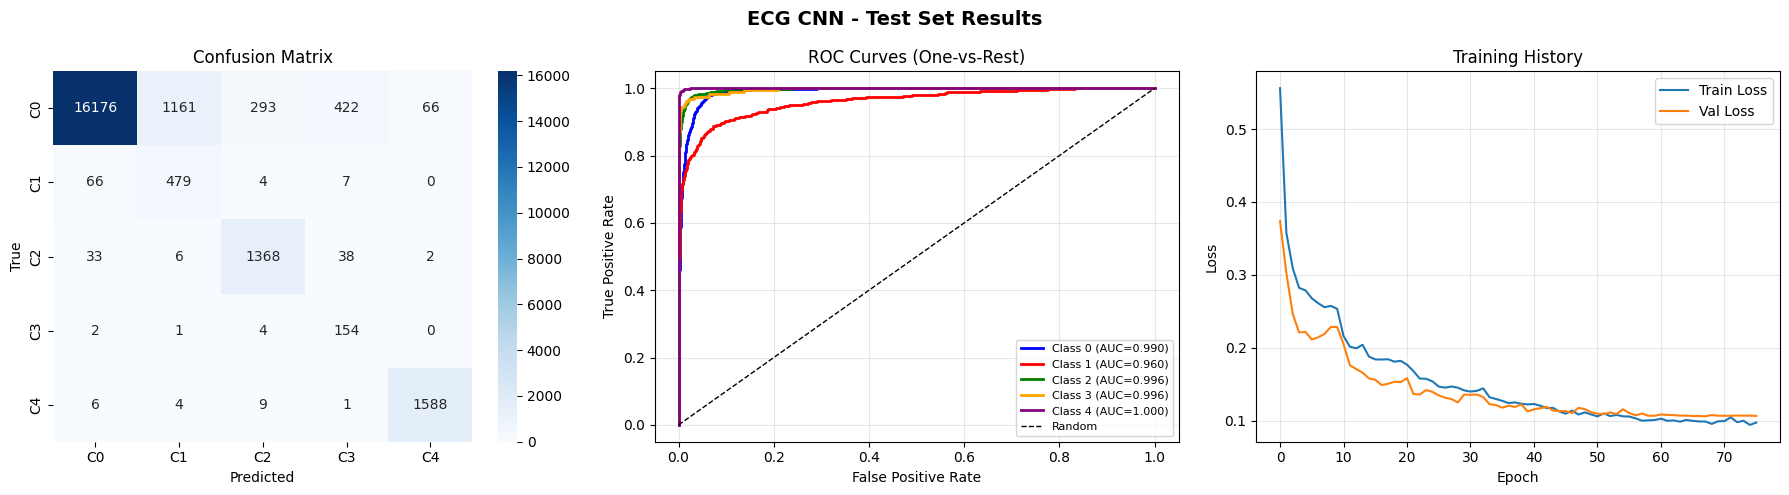

Plots generated


In [ ]:
print('=' * 60)
print('TEST SET EVALUATION')
print('=' * 60)

y_pred_proba = final_model.predict(X_test_r, verbose=0)
y_pred       = np.argmax(y_pred_proba, axis=1)

print('\nPredicted vs actual class distribution:')
print(f'{"Class":<8} {"Predicted":>12} {"Actual":>12}')
print('-' * 35)
for i in range(5):
    pred_cnt = (y_pred == i).sum()
    true_cnt = (y_test == i).sum()
    print(f'  {i:<6} {pred_cnt:>12,} {true_cnt:>12,}')

acc         = accuracy_score(y_test, y_pred)
f1_weighted = f1_score(y_test, y_pred, average='weighted', zero_division=0)
f1_macro    = f1_score(y_test, y_pred, average='macro',    zero_division=0)

print(f'\nAccuracy      : {acc:.4f}')
print(f'F1 (Weighted) : {f1_weighted:.4f}')
print(f'F1 (Macro)    : {f1_macro:.4f}')
print('\nClassification Report:')
print(classification_report(y_test, y_pred,
      target_names=[f'Class {i}' for i in range(5)], zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3, 4])

# Plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ECG CNN - Test Set Results', fontsize=14, fontweight='bold')

# Confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=[f'C{i}' for i in range(5)],
            yticklabels=[f'C{i}' for i in range(5)])
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix')

# ROC curves
y_test_bin = label_binarize(y_test, classes=[0, 1, 2, 3, 4])
colors = cycle(['blue', 'red', 'green', 'orange', 'purple'])
for i, color in zip(range(5), colors):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_pred_proba[:, i])
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2,
                 label=f'Class {i} (AUC={roc_auc:.3f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves (One-vs-Rest)')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(True, alpha=0.3)

# Training history
axes[2].plot(history_final.history['loss'],     label='Train Loss')
axes[2].plot(history_final.history['val_loss'], label='Val Loss')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Loss')
axes[2].set_title('Training History')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/ecg_cnn_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plots generated')

## Cell 11 - Download Results


In [ ]:
from google.colab import files

files.download('figures/ecg_cnn_results.png')

final_model.save('ecg_cnn_model.keras')
files.download('ecg_cnn_model.keras')

print('\nResults summary:')
print(f'  Accuracy      : {acc:.4f}')
print(f'  F1 (Weighted) : {f1_weighted:.4f}')
print(f'  F1 (Macro)    : {f1_macro:.4f}')

FileNotFoundError: Cannot find file: figures/ecg_cnn_results.png